In [3]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta, timezone
from CFA.cfa import CFA as cfa

In [4]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
russell1000 = market.retrieve("russell1000")
market.disconnect()

In [14]:
holding_period = 5
tickers = russell1000["ticker"].values
positions = 10
hedge_percentage = 0.05
training_year = datetime.now().year - 3
today = datetime.now()
weekday = today.weekday() - 1 if today.weekday() != 0 else 4
week = today.isocalendar()[1] if today.weekday() != 0 else today.isocalendar()[1] - 1
week_mod = int(week % (holding_period/5))
print(week_mod,week,weekday)

0 51 3


In [15]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        simulation = ticker_prices.copy()
        simulation.sort_values("date",inplace=True)
        simulation["historical_volatility"] = simulation["adjclose"].rolling(100).std() / simulation["adjclose"].rolling(100).mean()
        simulation["buy_price"] = simulation["adjclose"].shift(-1)
        simulation["buy_date"] = simulation["date"].shift(-1)
        simulation["sell_price"] = simulation["adjclose"].shift(-holding_period)
        simulation["sell_date"] = simulation["date"] + timedelta(days=int(holding_period /5) * 7)
        simulation["return"] = (simulation["sell_price"] - simulation["buy_price"]) / simulation ["buy_price"] * (1/positions) *0.99
        simulation["return"] = [max(float(-hedge_percentage/positions),x) for x in simulation["return"]]
        prices.append(simulation)
    except Exception as e:
        print(ticker,str(e))
        continue
market.disconnect()

model_prep: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1009/1009 [00:48<00:00, 20.91it/s]


In [16]:
sim = pd.concat(prices).reset_index(drop=True)
sim.sort_values("date",inplace=True)
trades = sim[sim["weekday"]==weekday].copy()
trades = trades[trades["week"] % int(holding_period/5) == week_mod]
trades = processor.column_date_processing(trades)

In [17]:
valuation_method = "historical_volatility"

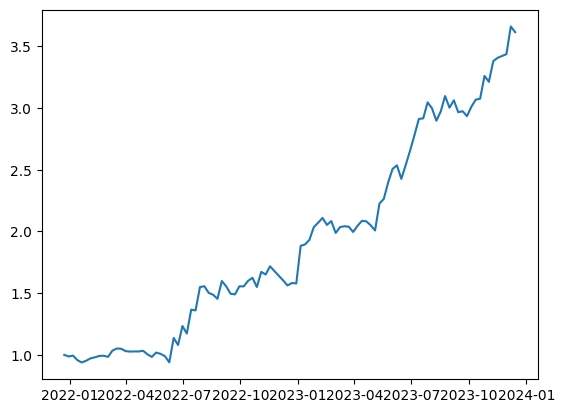

In [18]:
try:
    iteration_trades = trades.copy().sort_values(valuation_method,ascending=False).groupby(["date"]).nth([i for i in range(positions)]).reset_index()
    portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
    portfolio.sort_values("date",inplace=True)
    portfolio["year"] = [x.year for x in portfolio["date"]]
    portfolio = portfolio[(portfolio["date"]<portfolio["date"].max()) & (portfolio["year"]>=training_year)]
    portfolio["return"] = portfolio["return"] + 1
    portfolio["cumulative_return"] = portfolio["return"].cumprod()
    portfolio = processor.column_date_processing(portfolio)
    portfolio.dropna(inplace=True)
    recommendations = iteration_trades[["date","sell_date","ticker","adjclose",valuation_method]].sort_values(["date"]).tail(positions)
    plt.plot(portfolio["date"].values,portfolio["cumulative_return"].values)
    plt.show()
except Exception as e:
    print(str(e))

In [19]:
portfolio.sort_values("date",ascending=False)

,date,return,year,cumulative_return,quarter,month,week,weekday
101,2023-12-14 05:00:00+00:00,0.987485,2023,3.613891,4,12,50,3
100,2023-12-07 05:00:00+00:00,1.065218,2023,3.659694,4,12,49,3
99,2023-11-30 05:00:00+00:00,1.008728,2023,3.435630,4,11,48,3
98,2023-11-16 05:00:00+00:00,1.007767,2023,3.405904,4,11,46,3
97,2023-11-09 05:00:00+00:00,1.052355,2023,3.379654,4,11,45,3
...,...,...,...,...,...,...,...,...
4,2022-01-20 05:00:00+00:00,0.980224,2022,0.939298,1,1,3,3
3,2022-01-13 05:00:00+00:00,0.963452,2022,0.958248,1,1,2,3
2,2022-01-06 05:00:00+00:00,1.006635,2022,0.994600,1,1,1,3
1,2021-12-30 05:00:00+00:00,0.987101,2021,0.988044,4,12,52,3


In [20]:
iteration_trades.sort_values("return",ascending=False).head(10)

,index,date,adjclose,ticker,year,quarter,month,week,weekday,historical_volatility,buy_price,buy_date,sell_price,sell_date,return
211,415185,2023-01-05 05:00:00+00:00,8.43,SHC,2023,1,1,1,3,0.445359,8.46,2023-01-06 05:00:00+00:00,18.28,2023-01-12 05:00:00+00:00,0.114915
162,113682,2022-07-28 04:00:00+00:00,62.25,COIN,2022,3,7,30,3,0.497775,62.96,2022-07-29 04:00:00+00:00,88.90,2022-08-04 04:00:00+00:00,0.040789
178,113672,2022-07-14 04:00:00+00:00,53.42,COIN,2022,3,7,28,3,0.472142,53.79,2022-07-15 04:00:00+00:00,73.98,2022-07-21 04:00:00+00:00,0.037160
442,7690,2022-06-30 04:00:00+00:00,18.06,AFRM,2022,2,6,26,3,0.341730,17.19,2022-07-01 04:00:00+00:00,23.34,2022-07-07 04:00:00+00:00,0.035419
221,415153,2022-11-17 05:00:00+00:00,5.95,SHC,2022,4,11,46,3,0.435435,6.02,2022-11-18 05:00:00+00:00,8.15,2022-11-24 05:00:00+00:00,0.035028
665,470064,2023-07-27 04:00:00+00:00,25.32,VRT,2023,3,7,30,3,0.276258,25.95,2023-07-28 04:00:00+00:00,34.50,2023-08-03 04:00:00+00:00,0.032618
348,349430,2022-07-14 04:00:00+00:00,8.34,PTON,2022,3,7,28,3,0.377948,8.48,2022-07-15 04:00:00+00:00,11.26,2022-07-21 04:00:00+00:00,0.032455
431,461663,2022-06-16 04:00:00+00:00,32.85,U,2022,2,6,24,3,0.343905,35.48,2022-06-17 04:00:00+00:00,46.81,2022-06-23 04:00:00+00:00,0.031614
460,36702,2023-08-17 04:00:00+00:00,30.90,APLS,2023,3,8,33,3,0.334381,30.65,2023-08-18 04:00:00+00:00,40.08,2023-08-24 04:00:00+00:00,0.030459
188,22940,2023-01-05 05:00:00+00:00,3.96,AMC,2023,1,1,1,3,0.466965,3.85,2023-01-06 05:00:00+00:00,5.02,2023-01-12 05:00:00+00:00,0.030086


In [21]:
recommendations

,date,sell_date,ticker,adjclose,historical_volatility
310,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,CELH,50.29,0.392602
232,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,HE,13.96,0.428414
179,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,CHPT,2.44,0.472134
541,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,SRE,73.14,0.308038
350,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,AFRM,47.94,0.376823
387,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,NVCR,13.35,0.363183
522,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,PLUG,4.41,0.313266
575,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,AMC,6.07,0.300137
572,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,GPS,21.25,0.301778
524,2023-12-21 05:00:00+00:00,2023-12-28 05:00:00+00:00,WOOF,3.05,0.312489


In [22]:
db.connect()
db.drop('portfolio')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",iteration_trades)
db.store("recommendations",recommendations)
db.disconnect()